# Churn SaaS — pipeline de données

Estimer la probabilité de résiliation d'un client à l'échéance, à partir de
`docs/churn_saas_complet.csv` (5035 lignes, 28 % de churn).

**Prérequis** : `docker compose up -d` — PostgreSQL sur le port 5432, pgAdmin sur
http://localhost:5050.

## 🥉🥈🥇 Ingestion complète

Lance les trois couches à la suite : `docs/*.csv` → 🥉 bronze → 🥈 silver →
🥇 gold. Chaque couche est intégralement rechargée, l'exécution est donc
rejouable sans créer de doublons.

In [ ]:
from ml_churn.ingestion.scripts.ingest_all import ingest_all

lignes_ingestion = ingest_all()

## 1. Exploration des données brutes

Deux types de graphiques construits directement sur le CSV, avant toute
ingestion. Les valeurs sont normalisées à la volée — le CSV mélange les casses
(`TPE`, `tpe`, `" TPE "`) et les unités (`20.0%`, `3.1 h`, `280.62 €`).

**Histogrammes** — répartition des clients par secteur, pays, taille
d'entreprise et plan, puis distribution des variables d'usage (ancienneté,
CSAT, délai de réponse du support, revenu mensuel…).

**Boîtes à moustaches** — complémentaires : là où l'histogramme montre la forme
de la distribution, le boxplot isole individuellement chaque point au-delà de
1,5 × IQR, même s'il n'y en a qu'un sur 5000. Les variables très asymétriques
sont tracées en échelle logarithmique ; en linéaire, le critère IQR classe
toute la traîne en valeurs extrêmes et écrase la boîte.

Les PNG sont exportés dans `src/visualization/graphs/<type>/<préfixe>_<donnée>.png`.

In [ ]:
import sys

sys.path.insert(0, "src")  # src/visualization n'est pas un package installe
from visualization.scripts.plot_all import plot_all

graphiques = plot_all()

## 🥉 2. Ingestion — couche bronze

Les trois CSV de `docs/` sont copiés **tels quels** dans le schéma `bronze` :
toutes les colonnes métier en `TEXT`, aucune conversion ni nettoyage. Chaque ligne
conserve son origine (`_source_file`, `_source_line`, `_ingested_at`).

Les tables sont vidées puis rechargées : relancer la cellule ne crée pas de
doublons. Le log compare les lignes lues dans le CSV à celles réellement insérées
en base, et signale tout écart.

In [ ]:
from ml_churn.ingestion.scripts.ingest_bronze import ingest_bronze

lignes_bronze = ingest_bronze()

## 🥈 3. Ingestion — couche silver

`bronze.churn_saas_complet_bronze` → `silver.churn_saas_silver`, en onze actions
successives :

1. **Déduplication** sur `client_id`
2. **Standardisation** de huit colonnes : dates ramenées au format `AAAA-MM-JJ`,
   pays en codes ISO, plans en `PRO`/`BUS`/`STR`/`ENT`, casse et espaces harmonisés
3. **Règles métier** : toute ligne hors bornes est supprimée
4. **Typage** : `date`, `integer` et `numeric` selon la colonne

In [ ]:
from ml_churn.ingestion.scripts.ingest_silver import ingest_silver

lignes_silver = ingest_silver()

## 🥇 4. Ingestion — couche gold

`silver` → `gold`, pour les deux tables : `catalogue_gold` et
`churn_saas_gold`. Les tables reprennent **la structure de silver à
l'identique** (mêmes colonnes, mêmes types) — les définitions sont partagées
via les mixins de `models/colonnes.py`, il n'y a donc pas deux schémas à
maintenir.

Gold est la couche stable sur laquelle s'appuient l'analyse et la
modélisation, sans dépendre des retraitements successifs de silver.

In [ ]:
from ml_churn.ingestion.scripts.ingest_gold import ingest_gold

lignes_gold = ingest_gold()

## 5. Déséquilibre de la cible

Effectifs de chaque valeur de `churn` et taux de résiliation, lus dans
`gold.churn_saas_gold`. Le code est dans `src/ml_churn/training/`.

Ce déséquilibre conditionne le choix des métriques : un modèle qui prédirait
« personne ne résilie » aurait déjà une exactitude égale à la part de clients
actifs.

In [ ]:
from ml_churn.training.classification.analyze_target import analyze_target

repartition_cible = analyze_target()

## 6. Classification — baseline (régression logistique)

```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

**Entraînement du modèle baseline.** Un modèle de regréssion logistique est utilisé pour avoir un point de référence de comparaison pour les modèles plus complèxes.
Tous les paramètres du modèle sont laissés par défaut (seuil a 0.5) et le modèle est enregistré dans `artifacts/baseline/<date>/`.

[SEUIL] 0.50
[DONNEES] : 5000 clients, 64 features
  exclues : client_id, code_datacenter, couleur_theme_interface, date_souscription, groupe_experimentation, jour_souscription, niveau_anciennete, pays, plan, polarite_csm, sante_compte_fin_periode, secteur, taille_entreprise, valeur_vie_client_eur
  train 3000 / validation 1000 / test 1000  (churn 28.00% dans le test)

[PERFORMANCE] sur le jeu de test
  accuracy              0.81   (TP+TN) / (TP+TN+FP+FN)
  recall                0.80   TP / (TP+FN)
  false_positive_rate   0.19   FP / (FP+TN)
  precision             0.62   TP / (TP+FP)
  auc                   0.88   aire sous la courbe ROC (independante du seuil)

[MATRICE DE CONFUSION]
                       predit reste       predit churn
  reel reste               TN = 584           FP = 136
  reel churn                FN = 56           TP = 224

  TP = 224   churners detectes
  FN = 56    churners manques
  FP = 136   fausses alertes
  TN = 584   clients fideles correctement identif

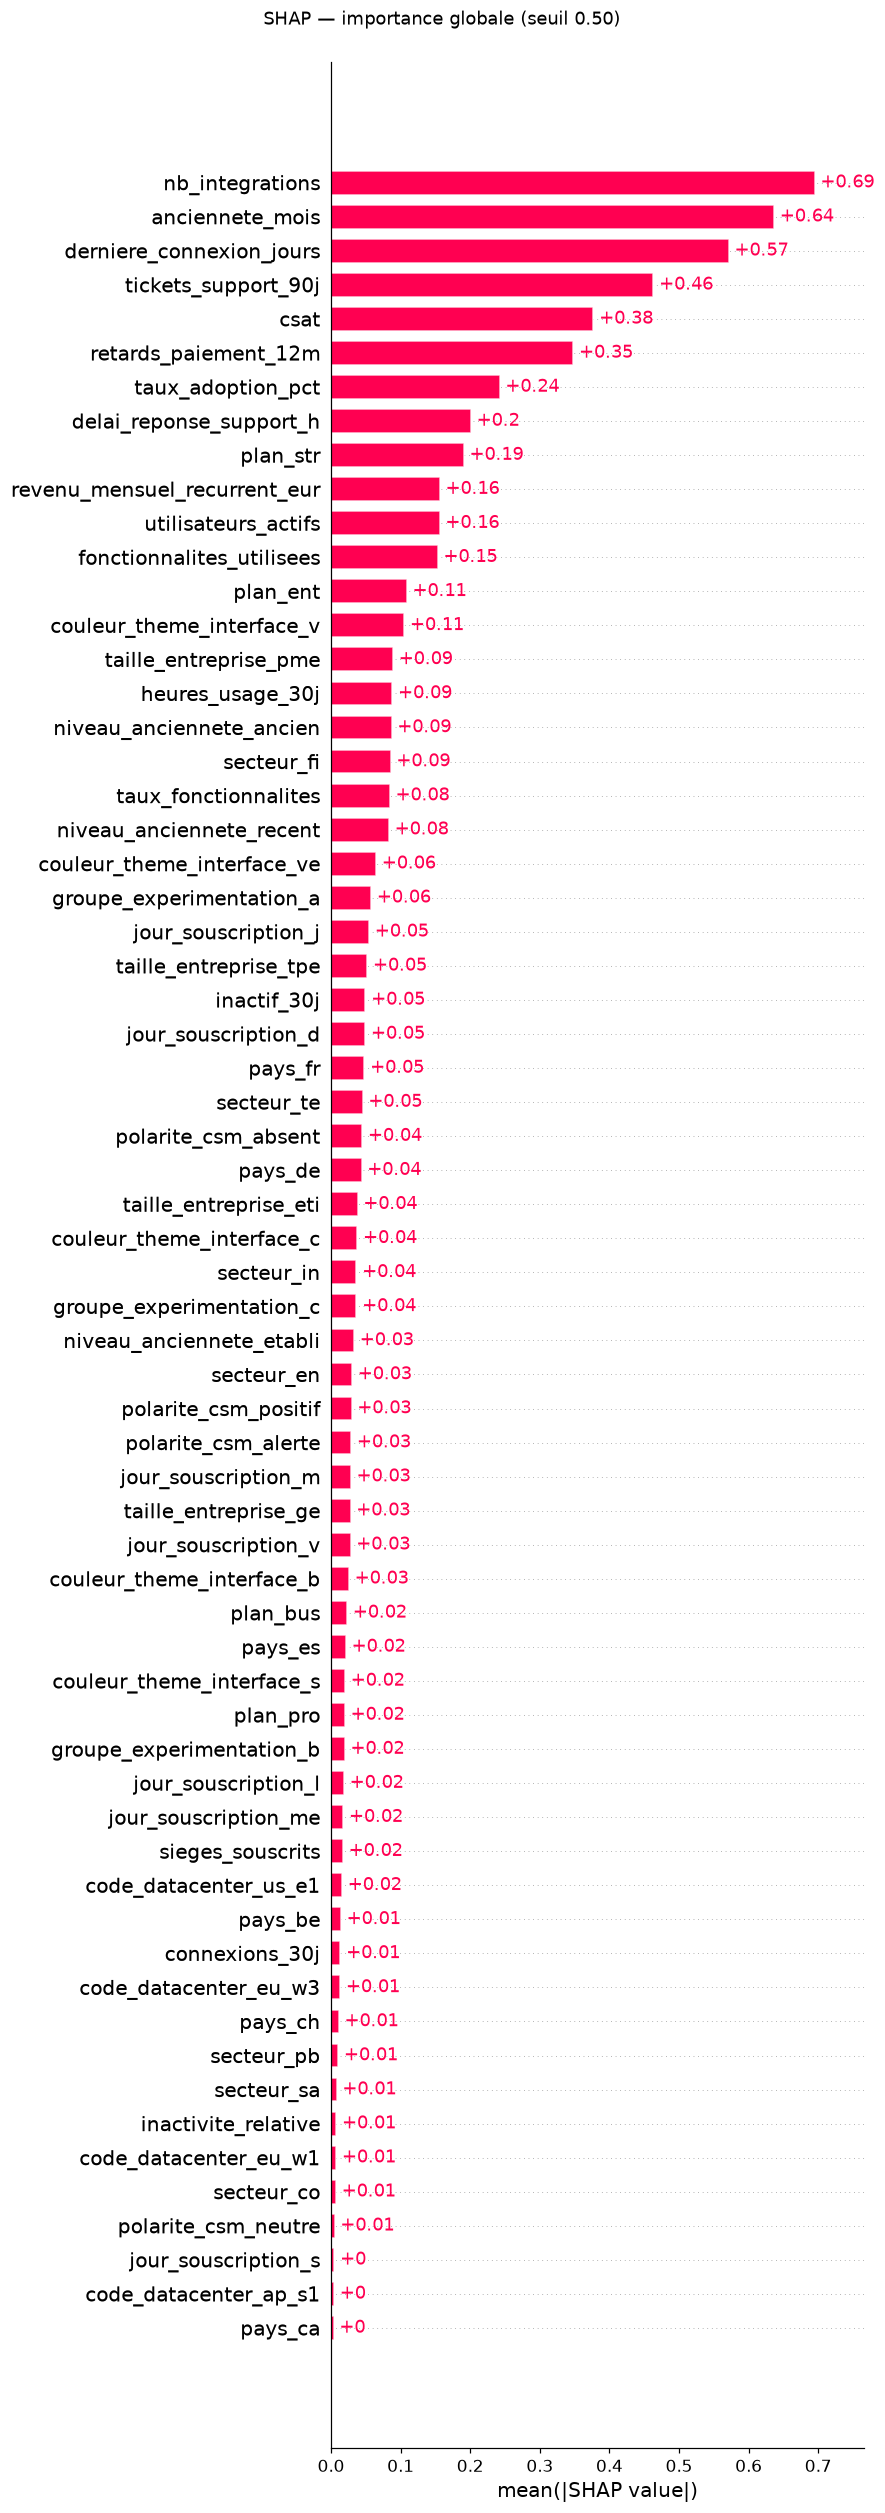

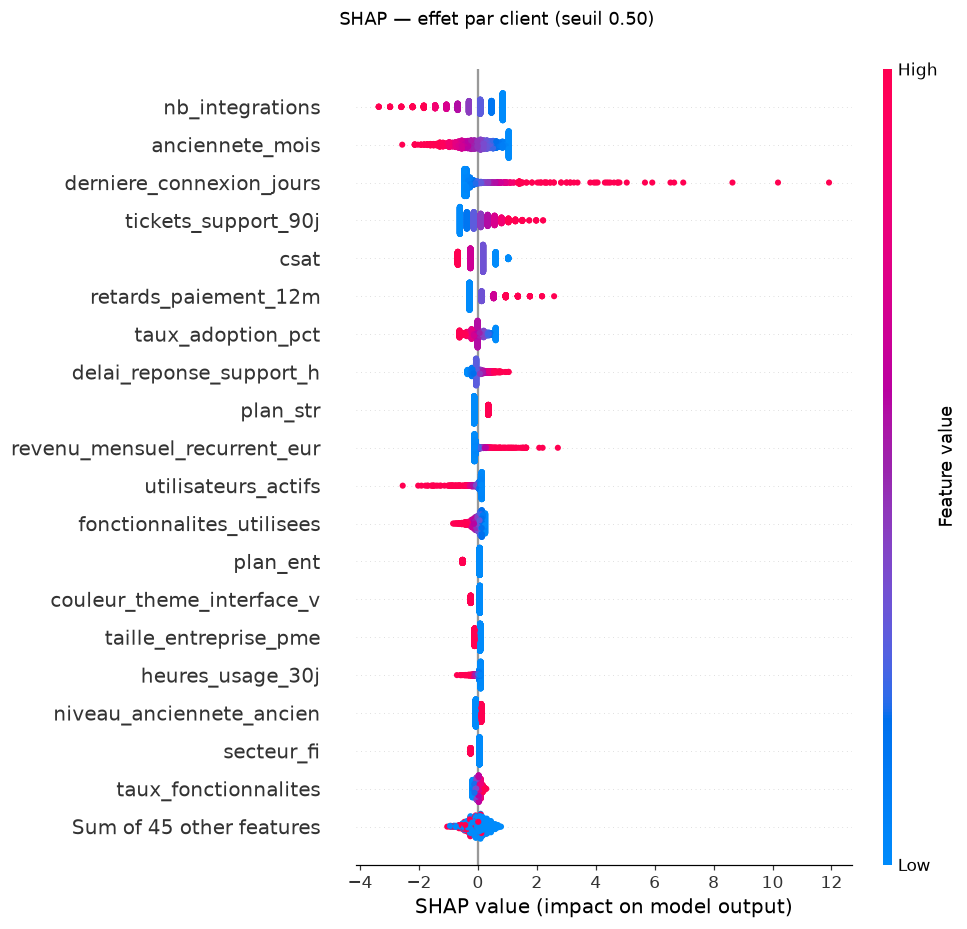

In [2]:
from ml_churn.training.classification.baseline.classification_baseline_training import (
    train_classification_baseline,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

# Seuil par defaut : 0.5.
resultat_baseline = train_classification_baseline()

# Explication sur le jeu de test : ce que le modele a appris se juge sur des
# lignes qu'il n'a pas vues.
display_figure(
    shap_bar_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — importance globale (seuil {resultat_baseline.seuil:.2f})",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — effet par client (seuil {resultat_baseline.seuil:.2f})",
    )
)


**Explication des features du baseline modèle avec SHAP :**

**Tableau :**
- **Hypothétisé :** Il s'agit d'une colonne dont j'ai hypothétisé ou non comme étant responsable du churn (positivement ou négativement)
- **Fortes valeurs :** impact d'une valeur forte sur le churn
- **Faibles valeurs :** impact d'une valeur faible sur le churn
- ⬆️ : impact le churn de manière positif
- ⬇️ : impact le churn de manière négative


| # | Feature | Hypothétisé | Fortes valeurs | Faibles valeurs |
|---|---------|:-----------:|:--------------:|:---------------:|
| 1 | nb_integrations | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 2 | anciennete_mois | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 3 | derniere_connexion_jours | | ⬆️⬆️⬆️ | ⬇️⬇️ |
| 4 | tickets_support_90j | ✅ | ⬆️⬆️⬆️ | ⬇️⬇️⬇️ |
| 5 | csat | ✅ | ⬇️⬇️ | ⬆️⬆️ |
| 6 | retards_paiement_12m | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 7 | taux_adoption_pct | | ⬇️⬇️ | ⬆️⬆️ |
| 8 | delai_reponse_support_h | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 9 | plan_str | | ⬆️⬆️ | ⬇️ |
| 10 | revenu_mensuel_recurrent_eur | | ⬆️⬆️ | ⬇️ |
| 11 | utilisateurs_actifs | ✅ | ⬇️⬇️ | ⬆️ |
| 12 | fonctionnalites_utilisees | ✅ | ⬇️⬇️ | ⬆️ |
| 13 | plan_ent | | ⬇️⬇️⬇️ | ⬆️ |
| 14 | couleur_theme_interface_v | | ⬇️⬇️ | ⬆️ |
| 15 | taille_entreprise_pme | ✅ | ⬇️ | ⬆️ |
| 16 | heures_usage_30j | | ⬇️ | ⬆️ |
| 17 | niveau_anciennete_ancien | | ⬆️ | ⬇️ |
| 18 | secteur_fi | | ⬇️⬇️ | ⬆️ |
| 19 | taux_fonctionnalites | | ⬆️ | ⬇️ |
| 20 | niveau_anciennete_recent | | ⬇️⬇️ | ⬆️ |

## 7. Classification — recherche des hyperparamètres optimaux (XGBoost)

Même cible, même découpage et mêmes exclusions que la baseline : les deux
modèles restent comparables.

La cellule enchaîne deux étapes : **recherche** sur les neuf hyperparamètres
suivants plus le seuil de décision, puis **réentraînement** avec les valeurs
retenues et mesure sur le jeu de test tenu à l'écart jusque-là — c'est ce
modèle qui est versionné dans `artifacts/` — puis les deux lectures **SHAP**
des contributions, comme pour la baseline. Les valeurs viennent ici de
`TreeExplainer`, qui parcourt les arbres au lieu de supposer un effet
linéaire.

| Hyperparamètre | Plage explorée | Rôle |
|---|---|---|
| `n_estimators` | 100 → 800 | Nombre d'arbres |
| `max_depth` | 2 → 8 | Profondeur maximale d'un arbre |
| `learning_rate` | 0.01 → 0.3 | Pas d'apprentissage entre deux arbres |
| `subsample` | 0.6 → 1.0 | Part des lignes tirées par arbre |
| `colsample_bytree` | 0.4 → 1.0 | Part des colonnes tirées par arbre |
| `min_child_weight` | 1 → 20 | Poids minimal d'une feuille |
| `gamma` | 0.0 → 5.0 | Gain minimal exigé pour un découpage |
| `reg_alpha` | 1e-8 → 10 | Pénalité L1 sur les poids des feuilles |
| `reg_lambda` | 1e-8 → 10 | Pénalité L2 sur les poids des feuilles |
| `seuil` | 0.1 → 0.9 | Probabilité à partir de laquelle on alerte |

Les Hyperparamètres finaux et le seuil sont les suivants :


| Hyperparamètre | Valeur |
|---|---:|
| `seuil` | 0.40 |
| `n_estimators` | 300 |
| `max_depth` | 2 |
| `learning_rate` | 0.02 |
| `subsample` | 0.96 |
| `colsample_bytree` | 0.79 |
| `min_child_weight` | 8 |
| `gamma` | 4.58 |
| `reg_alpha` | 0.00 |
| `reg_lambda` | 3.58 |

Performances observées, sur la validation qui a servi à retenir ces valeurs
puis sur le test tenu à l'écart :

| Métrique | Validation | Test |
|---|---:|---:|
| score F2 | 0.78 | 0.78 |
| recall | 0.87 | 0.88 |
| false_positive_rate | 0.29 | 0.29 |
| precision | 0.54 | 0.54 |
| accuracy | 0.76 | 0.75 |
| auc | 0.88 | 0.87 |

Conclusion : l'écart entre validation et test est nul à deux décimales, la
recherche ne s'est donc pas sur-ajustée à la validation. Face à la baseline
réglée sur le même objectif F2 (recall 0.95, FPR 0.47), XGBoost détecte moins
de churners mais divise les fausses alertes par 1.6 — un arbitrage différent
à performance globale équivalente, les deux modèles ayant la même AUC.

In [ ]:
from ml_churn.training.classification.final.classification_xgboost_training import (
    train_classification_xgboost,
)
from ml_churn.training.classification.final.classification_xgboost_tuning import (
    tune_xgboost,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

# 1. Recherche des hyperparametres : un modele reentraine par essai.
resultat_tuning_xgboost = tune_xgboost(n_essais=100)

# 2. Reentrainement avec les hyperparametres retenus, puis mesure sur le jeu de
# test tenu a l'ecart. C'est ce modele qui est enregistre dans artifacts/.
resultat_xgboost = train_classification_xgboost(
    seuil=resultat_tuning_xgboost.seuil,
    hyperparametres=resultat_tuning_xgboost.hyperparametres,
)

# 3. Explication du modele sur le jeu de test.
display_figure(
    shap_bar_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — importance globale",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — effet par client",
    )
)

## 8. Classification — XGBoost sans les colonnes de contexte

De nombreuses features ont un très faible impact sur le modèle établie précédement, on va retirer les features suivantes :

| Colonne retirée | Modalités concernées |
|---|---|
| `groupe_experimentation` | `_a`, `_b`, `_c` |
| `code_datacenter` | `_eu_w1`, `_eu_w3`, `_us_e1`, `_ap_s1` |
| `couleur_theme_interface` | `_c`, `_ve`, `_b`, `_v`, `_s` |
| `plan` | `_str`, `_pro`, `_bus`, `_ent` |
| `taille_entreprise` | `_tpe`, `_pme`, `_eti`, `_ge` |
| `pays` | `_fr`, `_es`, `_ca`, `_de`, `_ch`, `_be` |
| `jour_souscription` | `_l`, `_m`, `_me`, `_j`, `_v`, `_s`, `_d` |
| `secteur` | `_te`, `_fi`, `_co`, `_sa`, `_in`, `_pb`, `_en` |

Entrainement d'un nouveau modèle avec exclusion des features :

In [ ]:
from ml_churn.training.classification.final.classification_xgboost_training import (
    exclusions_sans,
    train_classification_xgboost,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

COLONNES_RETIREES = (
    "groupe_experimentation",
    "code_datacenter",
    "couleur_theme_interface",
    "plan",
    "taille_entreprise",
    "pays",
    "jour_souscription",
    "secteur",
)

resultat_xgboost_reduit = train_classification_xgboost(
    seuil=resultat_tuning_xgboost.seuil,
    hyperparametres=resultat_tuning_xgboost.hyperparametres,
    exclusions=exclusions_sans(COLONNES_RETIREES),
    nom="classification_xgboost_sans_contexte",
)

# Explication du modele reduit sur le jeu de test.
display_figure(
    shap_bar_figure(
        resultat_xgboost_reduit.model,
        resultat_xgboost_reduit.X_test,
        titre="SHAP XGBoost sans contexte — importance globale",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_xgboost_reduit.model,
        resultat_xgboost_reduit.X_test,
        titre="SHAP XGBoost sans contexte — effet par client",
    )
)